In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt


In [8]:
# 1. Load the dataset
print("Loading data...")
df = pd.read_csv('delivery_data.csv')

Loading data...


In [9]:
# Separate Features (X) from the Target Label (y)
X = df.drop('delivery_time_min', axis=1)
y = df['delivery_time_min']

In [10]:
# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# 3. Scale the features (CRITICAL so distance and traffic scale equally)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Build the 3-Layer Neural Network for Regression (Prediction)
model = Sequential([
    Input(shape=(4,)),                      # Layer 1: INPUT LAYER (4 features)
    Dense(16, activation='relu'),           # Layer 2: HIDDEN LAYER (Finds complex patterns)
    Dense(1, activation='linear')           # Layer 3: OUTPUT LAYER (Linear activation for continuous numbers)
])

In [12]:
# 5. Compile the model
# loss='mse' (Mean Squared Error) penalizes big mistakes during training
# metrics=['mae'] (Mean Absolute Error) shows us how many minutes off we are on average
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [13]:
# 6. Train the model
print("\nStarting Training...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)


Starting Training...
Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2739.5681 - mae: 49.8308 - val_loss: 2502.9451 - val_mae: 47.5401
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2716.0571 - mae: 49.5922 - val_loss: 2480.2783 - val_mae: 47.2958
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2692.5225 - mae: 49.3516 - val_loss: 2457.4041 - val_mae: 47.0486
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2668.2307 - mae: 49.1030 - val_loss: 2433.6658 - val_mae: 46.7912
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2642.7178 - mae: 48.8406 - val_loss: 2408.6416 - val_mae: 46.5196
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2615.5674 - mae: 48.5617 - val_loss: 2381.7888 - val_mae: 46.2266
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2586.3201 - mae: 48.2603 - val_loss: 2353.0598 - val_mae: 45.9141
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2554.5857 - mae: 47.9348 - val_loss: 2322.1938 - val

## Visualize Training History

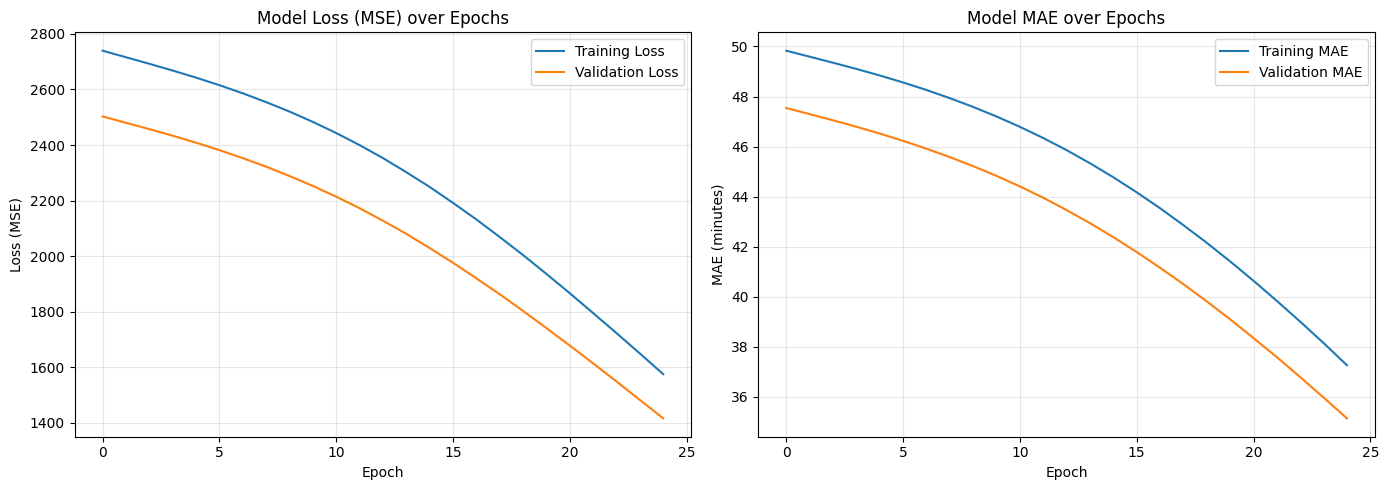

In [14]:
# 8. Visualize training history (Loss & MAE curves)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (MSE) curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss (MSE) over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE curve
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (minutes)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualize Predictions vs Actual (Test Set)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


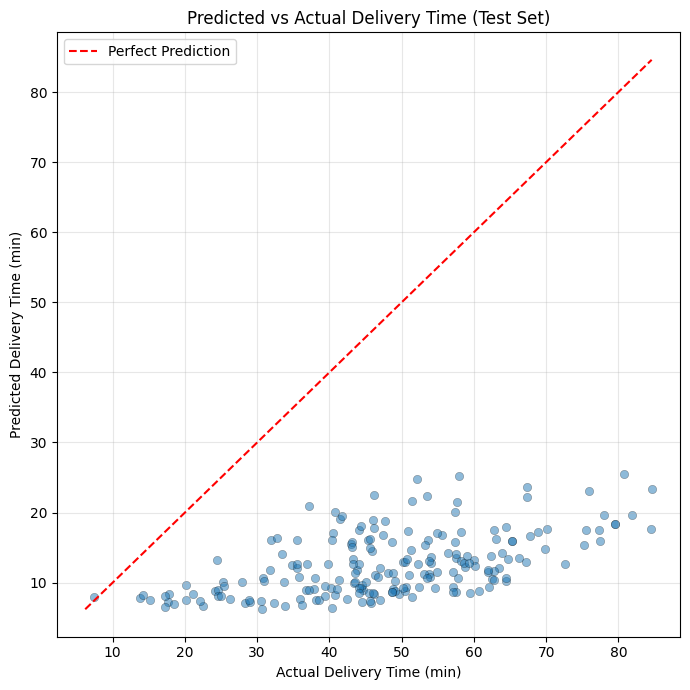

In [15]:
# 9. Compare predicted vs actual delivery times on the test set
y_pred_test = model.predict(X_test_scaled).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.5, edgecolor='k', linewidth=0.3)

# Perfect prediction reference line (y = x)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('Predicted vs Actual Delivery Time (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# 7. Test it with a "Live" Order
print("\n--- ESTIMATING LIVE ORDER DELIVERY TIME ---")
# Simulating a new order: 8.5km away, Traffic level 7, 15 min prep time, driver has 2 years experience
live_order = pd.DataFrame({
    'distance_km': [8.5],
    'traffic_index': [7],
    'prep_time_min': [15.0],
    'courier_exp_yrs': [2.0]
})

# Scale the live order using the same scaler
live_order_scaled = scaler.transform(live_order)

# Make the prediction
predicted_time = model.predict(live_order_scaled)

print(f"Estimated Delivery Time: {predicted_time[0][0]:.0f} minutes")


--- ESTIMATING LIVE ORDER DELIVERY TIME ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Estimated Delivery Time: 11 minutes


เเหล่งอ้างอิง : https://github.com/sandarsingh/Delivery-Time-Prediction-by-Sandar.git